In [1]:
import sys
sys.path.insert(0, '../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

In [2]:
SUBJECTS = helper_functions.fuglsang_get_subjects()


attended_envelope
  mat:  <NDVar 'attended_envelope': 192000 time> | mean=0.0755, std=0.0433
  self: <NDVar 'attended_envelope': 192000 time> | mean=1.8387, std=128.0571

ignored_envelope
  mat:  <NDVar 'ignored_envelope': 192000 time> | mean=0.0780, std=0.0426
  self: <NDVar 'ignored_envelope': 192000 time> | mean=2.2279, std=130.6563

attended_envelope_onset
  mat:  <NDVar 'attended_envelope_onset': 192000 time> | mean=0.0000, std=0.0000
  self: <NDVar 'attended_envelope_onset': 192000 time> | mean=0.0005, std=0.0605

ignored_envelope_onset
  mat:  <NDVar 'ignored_envelope_onset': 192000 time> | mean=0.0000, std=0.0000
  self: <NDVar 'ignored_envelope_onset': 192000 time> | mean=0.0006, std=0.0609


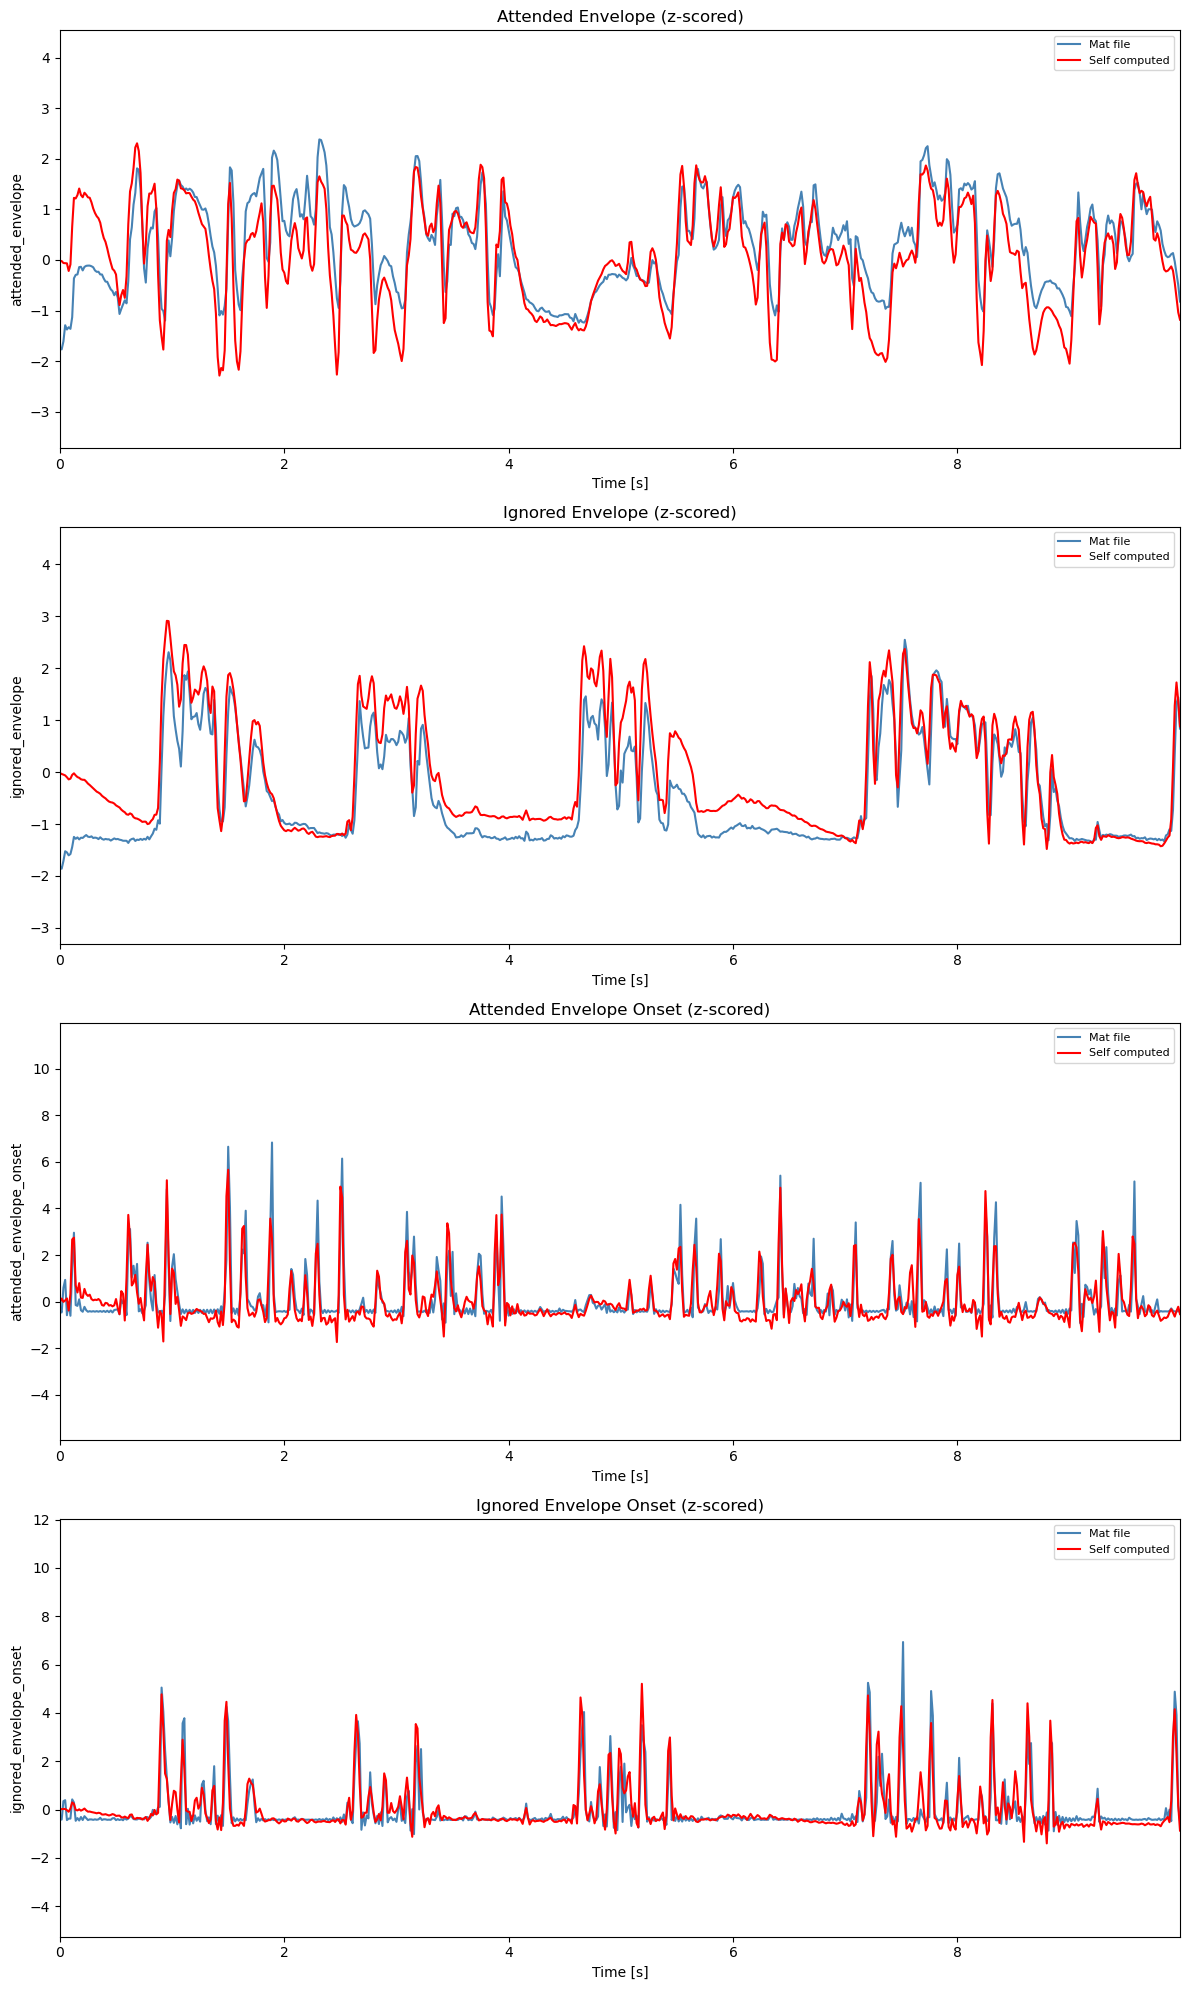

In [3]:
# %%
# Compare self-computed vs mat-file predictors for sanity check
subject    = SUBJECTS[3]
trial_idx  = 0  # first trial for visual comparison

compare_checks = [
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, False),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  False),
]

fig, axes = plt.subplots(len(compare_checks), 1, figsize=(12, 20), sharex=False)

for i, (predictor, attention, padded) in enumerate(compare_checks):
    name = helper_functions.get_attentional_predictor_name(predictor, attention, padded)

    mat_path  = FUGLSANG_PRED_CONCAT_MAT_DIR  / subject / f"{name}_concat.pickle"
    self_path = FUGLSANG_PRED_CONCAT_SELF_DIR / subject / f"{name}_concat.pickle"

    if not mat_path.exists():
        print(f"  ✗ Missing mat file:  {mat_path}")
        continue
    if not self_path.exists():
        print(f"  ✗ Missing self-computed: {self_path}")
        continue

    mat_pred  = eelbrain.load.unpickle(mat_path)
    self_pred = eelbrain.load.unpickle(self_path)

    # Z-score for visual comparison
    mat_z  = (mat_pred  - mat_pred.mean())  / mat_pred.std()
    self_z = (self_pred - self_pred.mean()) / self_pred.std()

    print(f"\n{name}")
    print(f"  mat:  {mat_pred} | mean={mat_pred.mean():.4f}, std={mat_pred.std():.4f}")
    print(f"  self: {self_pred} | mean={self_pred.mean():.4f}, std={self_pred.std():.4f}")

    eelbrain.plot.UTS(mat_z.sub(time=(0, 10)),  axes=axes[i], color='steelblue')
    eelbrain.plot.UTS(self_z.sub(time=(0, 10)), axes=axes[i], color='red')

    # Manual legend
    from matplotlib.lines import Line2D
    axes[i].legend(
        handles=[
            Line2D([0], [0], color='steelblue', label='Mat file'),
            Line2D([0], [0], color='red',       label='Self computed'),
        ],
        loc='upper right', fontsize=8
    )

    ymin   = min(mat_z.x.min(), self_z.x.min())
    ymax   = max(mat_z.x.max(), self_z.x.max())
    margin = 0.05 * (ymax - ymin)
    axes[i].set_ylim(ymin - margin, ymax + margin)
    axes[i].set_title(name.replace('_', ' ').title() + ' (z-scored)')
    #axes[i].legend(loc='upper right', fontsize=8)

plt.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / f'fuglsang_predictor_comparison_mat_vs_self.pdf', bbox_inches='tight')
plt.show()